In [45]:
## 1. Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [46]:
##2. Dataset Path

# --- FIX START: Restore Dataset Upload and Extraction Logic ---
import os
import zipfile
from google.colab import files

zip_file_name = "ai_project_synthetic_datasets.zip"
extracted_dir_name = "dataset" # The top-level directory where the zip extracts

# Define the path where the dataset should be extracted and where images are located
# This path is relative to the current working directory in Colab.
# Corrected: Prepend '/content/' to ensure correct absolute path within Colab
image_dir = f"/content/{extracted_dir_name}/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images"

# Check if the target image directory already exists to avoid re-extracting
if not os.path.exists(image_dir):
    print(f"Target image directory '{image_dir}' not found. Attempting to upload and extract dataset.")

    if not os.path.exists(zip_file_name):
        print(f"Please upload '{zip_file_name}'.")
        uploaded = files.upload()

        # Get the actual filename that was uploaded
        uploaded_filenames = list(uploaded.keys())
        if not uploaded_filenames:
            raise FileNotFoundError(f"No file was uploaded. Please ensure you upload '{zip_file_name}'.")

        actual_uploaded_filename = uploaded_filenames[0]

        if actual_uploaded_filename != zip_file_name:
            print(f"Uploaded file '{actual_uploaded_filename}' will be renamed to '{zip_file_name}'.")
            os.rename(actual_uploaded_filename, zip_file_name)
            print(f"'{zip_file_name}' uploaded successfully. Proceeding with extraction.")
        else:
            print(f"'{zip_file_name}' uploaded successfully. Proceeding with extraction.")
    else:
        print(f"'{zip_file_name}' already exists. Skipping upload.")

    # 2. Extract the dataset (if the extracted directory doesn't exist)
    if os.path.exists(zip_file_name) and not os.path.exists(extracted_dir_name):
        print(f"Extracting '{zip_file_name}'...")
        try:
            with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                zip_ref.extractall(extracted_dir_name)
            print(f"Dataset extracted to '{extracted_dir_name}'.")
        except zipfile.BadZipFile:
            print(f"Error: '{zip_file_name}' is not a valid zip file. Please check the uploaded file.")
        except Exception as e:
            print(f"Error extracting zip file: {e}")
    elif os.path.exists(extracted_dir_name):
        print(f"'{extracted_dir_name}' already exists. Skipping extraction.")
    else:
        print(f"Could not extract: '{zip_file_name}' not found after attempting upload.")
else:
    print(f"Image directory '{image_dir}' already exists. Skipping download and extraction.")

# --- FIX END ---

# Update dataset path for image preprocessing
DATASET_PATH = image_dir # Use the verified image_dir

# Clean class names (removing hidden files like .DS_Store)
# This line will now execute after the dataset is (attempted to be) downloaded and extracted
class_names = [f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))]
print(f"Classes Found: {class_names}")

Image directory '/content/dataset/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images' already exists. Skipping download and extraction.
Classes Found: ['normal', 'stain', 'dent', 'scratch']


In [47]:
#3. Image Preprocessing
IMG_SIZE = (96, 96)
BATCH_SIZE = 32

# Correcting DATASET_PATH to point to the actual directory containing class subfolders.
# This assumes the zip file extracted into /content/dataset and has the expected nested structure.
# DATASET_PATH = "/content/dataset/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images" # Removed redundant definition

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [48]:
# 4. Explore Dataset

print("Class Names:", train_data.class_indices)

classes = list(train_data.class_indices.keys())

# Count images per class
for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    print(f"{class_name}: {len(os.listdir(class_path))} images")

Class Names: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


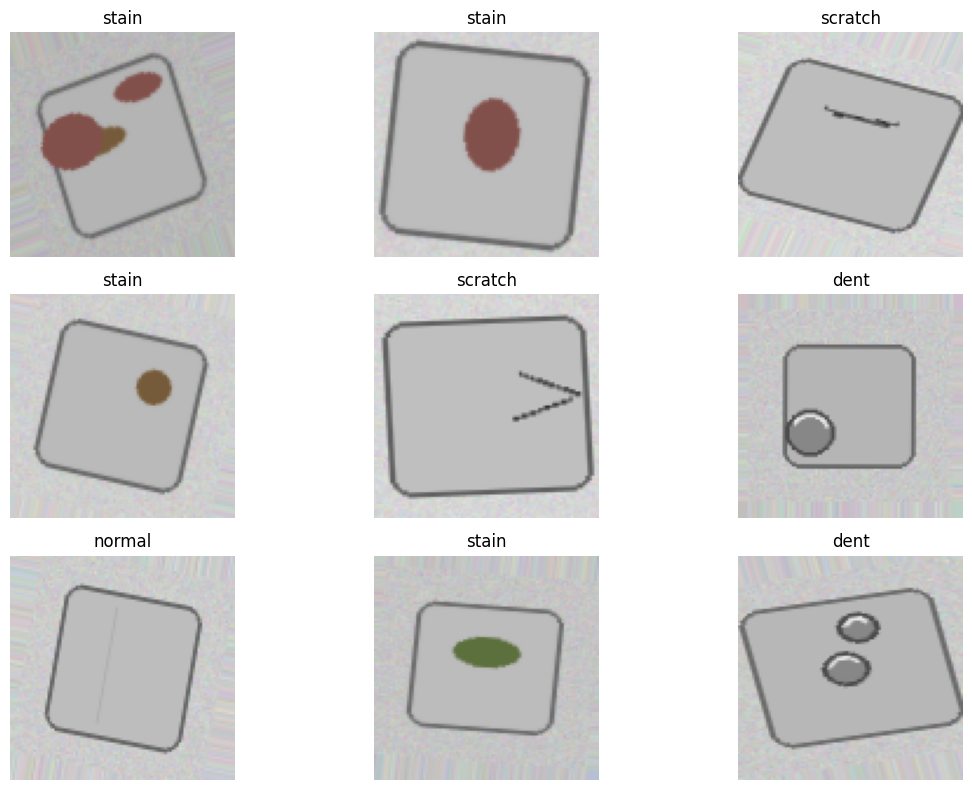

In [49]:
#5. Display Sample Images
images, labels = next(train_data)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
#6. Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
#7. Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
#8. Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 832ms/step - accuracy: 0.2526 - loss: 1.4233 - val_accuracy: 0.2500 - val_loss: 1.3845
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 671ms/step - accuracy: 0.2526 - loss: 1.3839 - val_accuracy: 0.3854 - val_loss: 1.3656
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 823ms/step - accuracy: 0.3620 - loss: 1.3246 - val_accuracy: 0.2812 - val_loss: 1.2759
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 776ms/step - accuracy: 0.5078 - loss: 1.1301 - val_accuracy: 0.5833 - val_loss: 0.9995
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 684ms/step - accuracy: 0.5807 - loss: 0.9127 - val_accuracy: 0.6042 - val_loss: 0.7517
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 790ms/step - accuracy: 0.6719 - loss: 0.7462 - val_accuracy: 0.8438 - val_loss: 0.6118
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 771ms/step - accuracy: 0.7708 - loss: 0.6316 - val_accuracy: 0.7500 - val_loss: 0.5241
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 645ms/step - accuracy: 0.7969 - loss: 0.5434 - val_accuracy: 

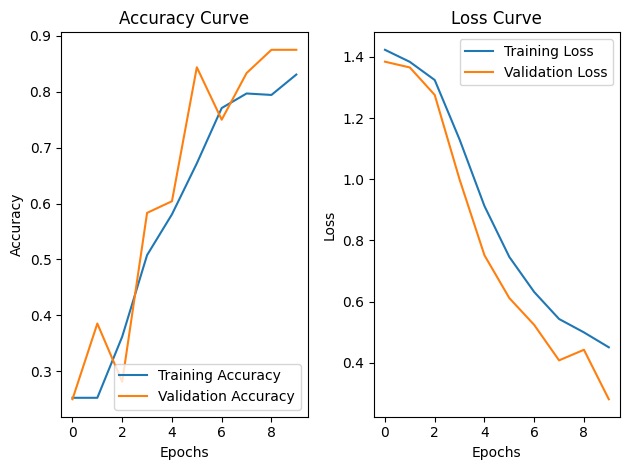

In [53]:
#9. Plot Accuracy and Loss Curves
# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png')
plt.show()

In [54]:
#10. Evaluate Model
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.8854 - loss: 0.2917
Validation Loss: 0.2916795015335083
Validation Accuracy: 0.8854166865348816


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step


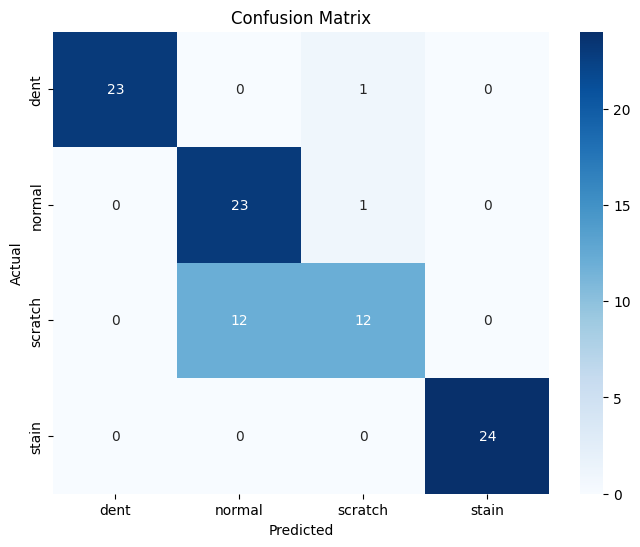

In [55]:
#11. Confusion Matrix
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png') # Added this line to save the plot
plt.show()

In [56]:
#12. Classification Report
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

        dent       1.00      0.96      0.98        24
      normal       0.66      0.96      0.78        24
     scratch       0.86      0.50      0.63        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.85        96
   macro avg       0.88      0.85      0.85        96
weighted avg       0.88      0.85      0.85        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


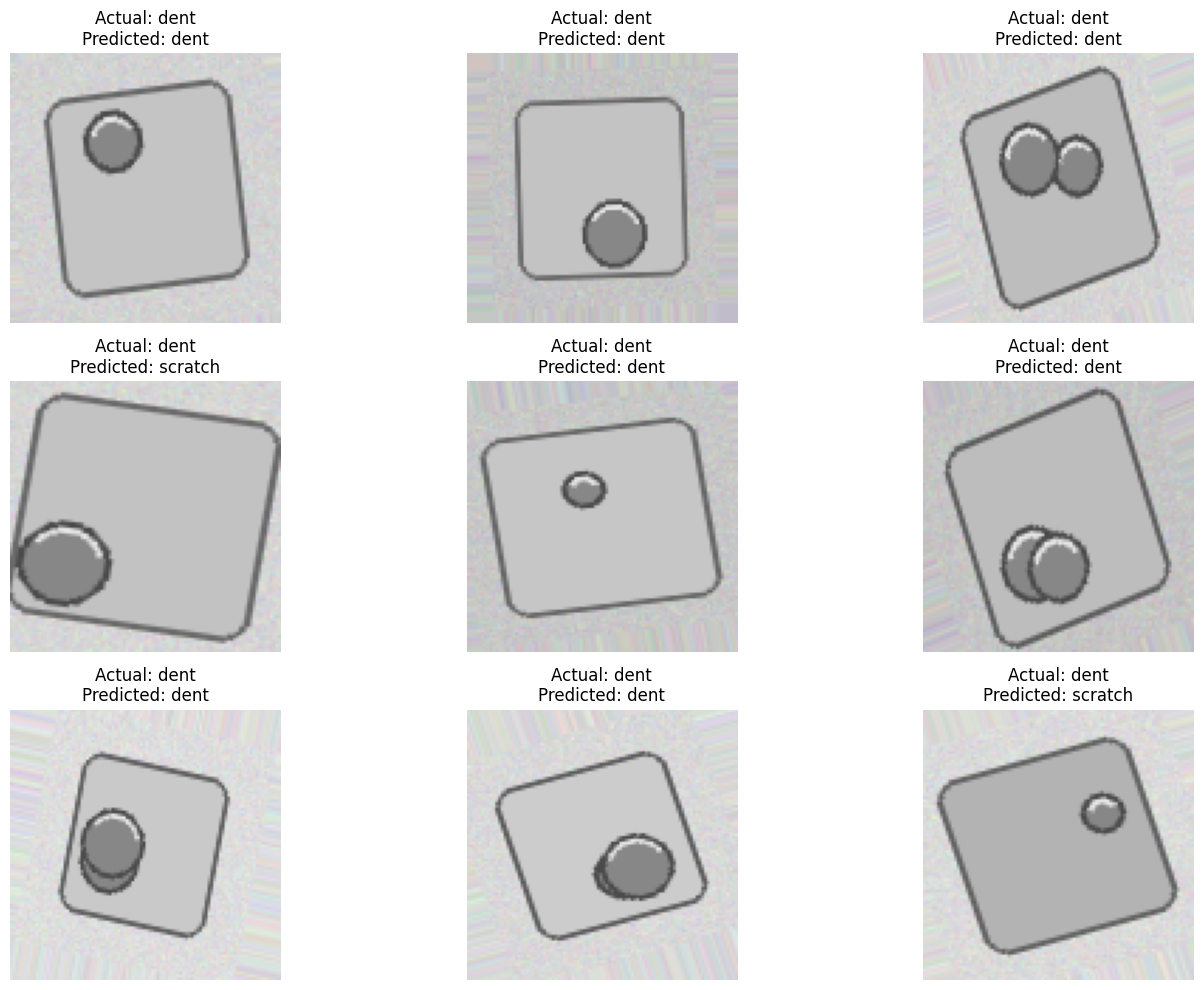

In [57]:
#13. Sample Predictions
images, labels = next(val_data)

predictions = model.predict(images)

plt.figure(figsize=(15,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    actual = classes[np.argmax(labels[i])]
    predicted = classes[np.argmax(predictions[i])]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png')
plt.show()

In [58]:
from google.colab import files

# Download all generated graph images
files.download('accuracy_loss_curves.png')
files.download('sample_predictions.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>